# chap 7

목차
1. 외계 행성 찾기
2. 오차 행렬
3. 불균형 데이터 리샘플링
4. 튜닝

## 1. 외계 행성 찾기

In [1]:
import pandas as pd
from pathlib import Path
file_dir = Path.cwd().parents[2] / "04_Resources" / "Dataset" / "XGBoost"
df = pd.read_csv(file_dir/"exoplanets.csv", nrows=500)
df.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [2]:
df["LABEL"].value_counts()

LABEL
1    463
2     37
Name: count, dtype: int64

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme()

In [4]:
y = df['LABEL'] - 1
X = df.drop('LABEL', axis=1)

In [5]:
def light_plot(index):
    y_vals = X.iloc[index]
    x_vals = np.arange(len(y_vals))
    plt.figure(figsize=(15,8))
    plt.xlabel('Number of Observations')
    plt.ylabel('Light Flux')
    plt.title('Light Plot ' + str(index), size=15)
    plt.plot(x_vals, y_vals)
    plt.show()

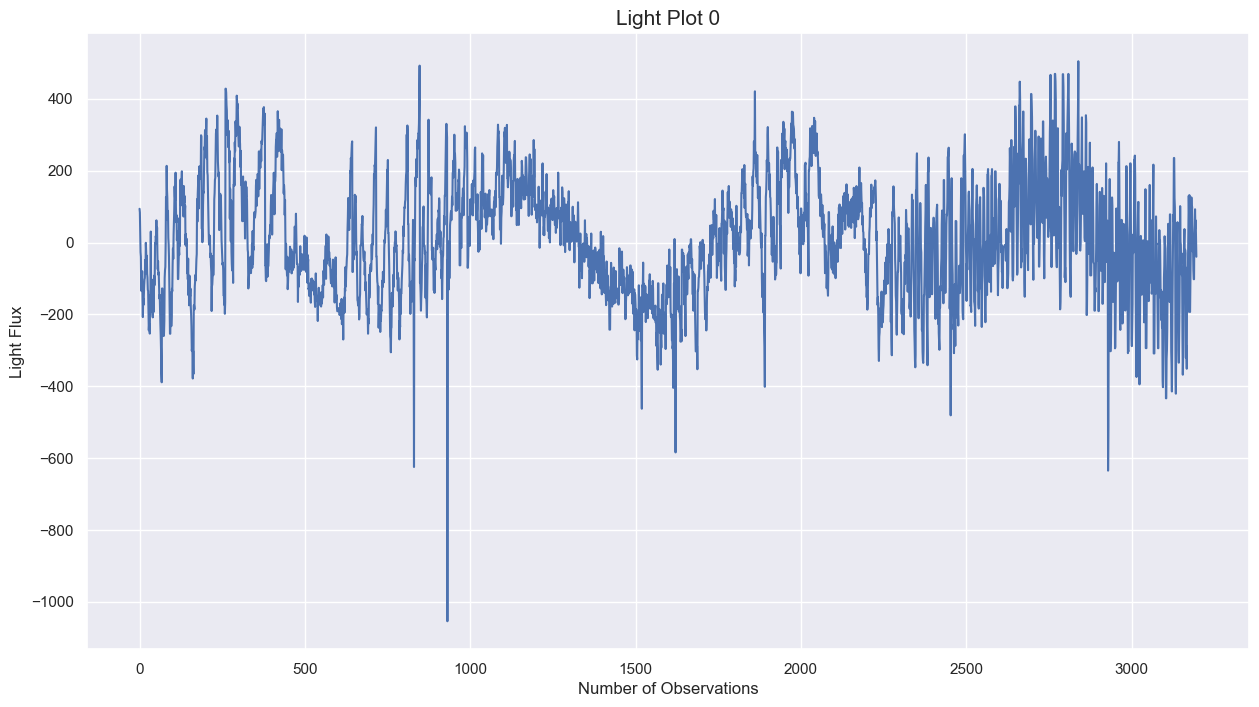

In [6]:
light_plot(0)

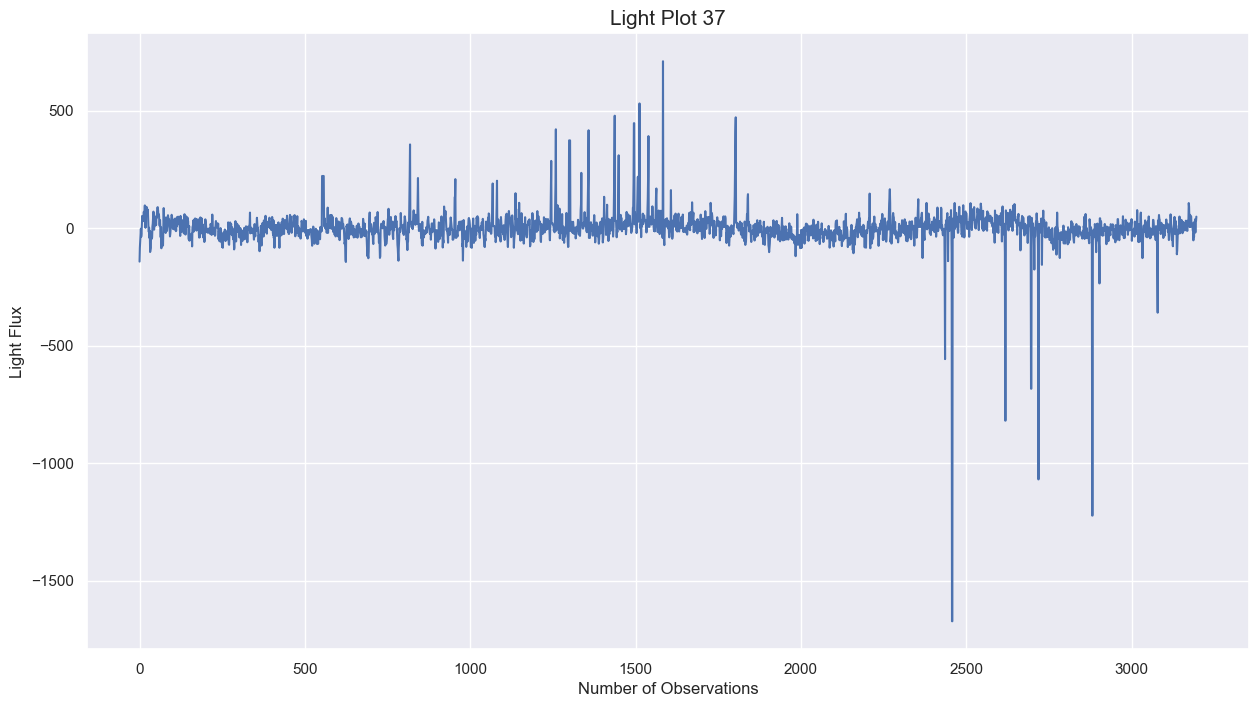

In [7]:
light_plot(37) # 외계행성 없음

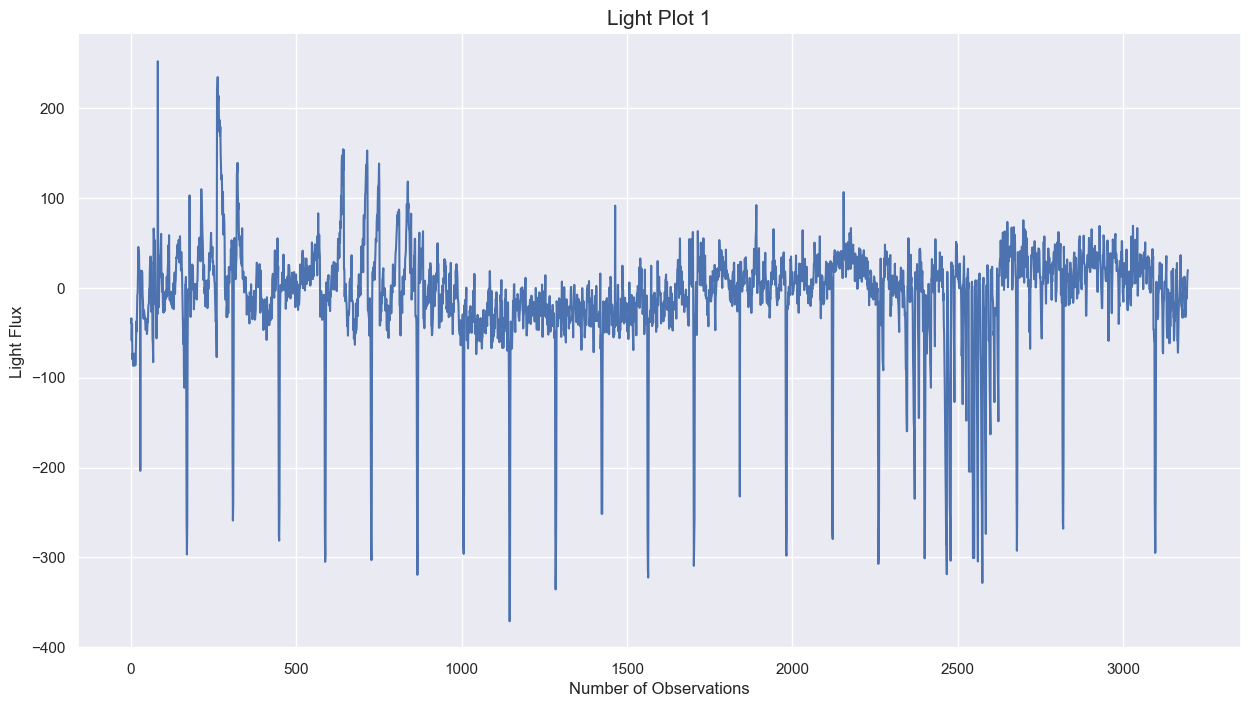

In [8]:
light_plot(1)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 12.2 MB


In [11]:
df.isna().sum().sum()

np.int64(0)

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2)

model = XGBClassifier(booster='gbtree')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print(f"점수: {score}")

점수: 0.92


이 예측의 문제점은 뭘까?

데이터 자체에 외계 행성을 가진 별이 10%밖에 없으므로 그냥 무조건 외계 행성이 없다고 하는 모델과 별 차이가 없다.

In [13]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[113,   1],
       [  9,   2]])

외계 행성이 없는 113개 별과 외계 행성이 있는 2개의 별을 올바르게 예측함

외계 행성이 있는 별을 없다고 잘못 분류한건 9개

행을 따라 분석해보면.. 외계 행성이 없는 114개 별 중 113개가 올바르게 분류, 외계 행성이 있는 11개 별 중 2개가 올바르게 분류

In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       114
           1       0.67      0.18      0.29        11

    accuracy                           0.92       125
   macro avg       0.80      0.59      0.62       125
weighted avg       0.90      0.92      0.90       125



1. 정밀도(precision): $TP/(TP + FP)$ 올바르게 양성으로 예측된 양성 샘플 개수 - 진짜 양성(tp), 거짓 양성(fp)
- tp: 올바르게 1로 예측된 1 개수
- tf: 올바르게 0으로 예측된 0 개수
2. 재현율(민감도, recall): $TP/(TP + FN)$ 제대로 예측한 양성 샘플 개수
- fn: 0으로 잘못 예측된 1 개수
3. F1-score: 정밀도와 재현율을 한 번에 평가 $2*(Precision*Recall)/(Precision+Recall)$

가능한 많은 외계행성을 찾아야 하므로 Recall을 사용

In [15]:
from sklearn.metrics import recall_score
recall_score(y_test, y_pred)

0.18181818181818182

### 3. 불균형 데이터 리샘플링

### 언더샘플링

5000개가 넘는 샘플 중 500개만 가져온것이 언더샘플링의 한 예시이다.


In [18]:
def xgb_clf(model, nrows):

    df = pd.read_csv(file_dir/'exoplanets.csv', nrows=nrows)
    # 데이터를 X와 y로 나눕니다.
    X = df.iloc[:,1:]
    y = df.iloc[:,0] - 1
    # 데이터를 훈련 세트와 테스트 세트로 나눕니다.
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2)
    # 훈련 세트에서 모델을 훈련합니다.
    model.fit(X_train, y_train)
    # 테스트 세트에 대한 예측을 만듭니다.
    y_pred = model.predict(X_test)
    score = recall_score(y_test, y_pred)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    return score

In [19]:
xgb_clf(XGBClassifier(), nrows=800)

[[190   0]
 [  9   1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       190
           1       1.00      0.10      0.18        10

    accuracy                           0.95       200
   macro avg       0.98      0.55      0.58       200
weighted avg       0.96      0.95      0.94       200



0.1

In [21]:
xgb_clf(XGBClassifier(), nrows=74)

[[5 3]
 [3 8]]
              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.73      0.73      0.73        11

    accuracy                           0.68        19
   macro avg       0.68      0.68      0.68        19
weighted avg       0.68      0.68      0.68        19



0.7272727272727273

### 오버샘플링

부족한 클래스의 샘플을 복사

In [22]:
df_train = pd.merge(y_train, X_train, left_index=True, right_index=True)
newdf = pd.DataFrame(np.repeat(df_train[df_train['LABEL']==1].values,
                               9,axis=0))
newdf.columns = df_train.columns
df_train_resample = pd.concat([df_train, newdf])

df_train_resample['LABEL'].value_counts()

LABEL
0.0    349
1.0    260
Name: count, dtype: int64

xgboost는 데이터 불균형에 매우 강하기때문에 리샘플링은 오히려 역효과가 될 확률이 **매우**높다

리샘플링 대신 scale_pos_weight 파라미터를 이용하는게 더 좋다

## 4. 튜닝

In [28]:
df = pd.read_csv(file_dir/"exoplanets.csv", nrows=400)
df['LABEL'] = df['LABEL'].replace({1:0, 2:1})
df['LABEL'].value_counts()

LABEL
0    363
1     37
Name: count, dtype: int64

In [34]:
y = df['LABEL']
X = df.drop('LABEL', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2, stratify=y)

weight_ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
model = XGBClassifier(scale_pos_weight=weight_ratio)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = recall_score(y_test, y_pred)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(score)

[[89  2]
 [ 6  3]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        91
           1       0.60      0.33      0.43         9

    accuracy                           0.92       100
   macro avg       0.77      0.66      0.69       100
weighted avg       0.91      0.92      0.91       100

0.3333333333333333


In [37]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=2)
model = XGBClassifier(scale_pos_weight=weight_ratio)
scores = cross_val_score(model, X, y, cv=kfold, scoring='recall')
print(f'recalls: {scores}')
print(f'recall mean: {np.mean(scores)}')

recalls: [0.21052632 0.27777778]
recall mean: 0.24415204678362573


In [39]:
def grid_search(params, random=False, X=X, y=y, 
                model=XGBClassifier(scale_pos_weight=10, random_state=2)): 
    xgb = model
    if random:
        grid = RandomizedSearchCV(xgb, params, cv=kfold, n_jobs=-1, 
                                  random_state=2, scoring='recall')
    else:
        # 그리드 서치 객체를 초기화합니다.
        grid = GridSearchCV(xgb, params, cv=kfold, n_jobs=-1, scoring='recall')
    # X_train와 y_train으로 훈련합니다.
    grid.fit(X, y)
    # 최상의 매개변수를 추출합니다.
    best_params = grid.best_params_
    # 최상의 매개변수를 출력합니다.
    print("최상의 매개변수:", best_params)
    # 최상의 점수를 추출합니다.
    best_score = grid.best_score_
    # 최상의 점수를 출력합니다.
    print("최상의 점수: {:.5f}".format(best_score))

In [40]:
grid_search(params={'n_estimators':[50, 200, 400, 800]})

최상의 매개변수: {'n_estimators': 50}
최상의 점수: 0.21637


In [41]:
grid_search(params={'learning_rate':[0.01, 0.05, 0.2, 0.3]})

최상의 매개변수: {'learning_rate': 0.01}
최상의 점수: 0.40351


In [42]:
grid_search(params={'max_depth':[1, 2, 4, 8]})

최상의 매개변수: {'max_depth': 2}
최상의 점수: 0.27047


In [43]:
grid_search(params={'subsample':[0.3, 0.5, 0.7, 0.9]})

최상의 매개변수: {'subsample': 0.3}
최상의 점수: 0.35380


In [44]:
grid_search(params={'gamma':[0.05, 0.1, 0.5, 1]})

최상의 매개변수: {'gamma': 1}
최상의 점수: 0.29825


In [45]:
grid_search(params={'learning_rate':[0.001, 0.01, 0.03], 
                    'max_depth':[1, 2], 'gamma':[0.025, 0.05, 0.5]})

최상의 매개변수: {'gamma': 0.025, 'learning_rate': 0.001, 'max_depth': 2}
최상의 점수: 0.56287


In [46]:
grid_search(params={'max_delta_step':[1, 3, 5, 7]})

최상의 매개변수: {'max_delta_step': 1}
최상의 점수: 0.21784


In [47]:
grid_search(params={'subsample':[0.3, 0.5, 0.7, 0.9, 1], 
                    'colsample_bylevel':[0.3, 0.5, 0.7, 0.9, 1], 
                    'colsample_bynode':[0.3, 0.5, 0.7, 0.9, 1], 
                    'colsample_bytree':[0.3, 0.5, 0.7, 0.9, 1]}, random=True)

최상의 매개변수: {'subsample': 0.3, 'colsample_bytree': 0.7, 'colsample_bynode': 0.9, 'colsample_bylevel': 1}
최상의 점수: 0.32602


In [48]:
X_short = X.iloc[:74, :]
y_short = y.iloc[:74]
grid_search(params={'max_depth':[1, 2, 3], 
                    'colsample_bynode':[0.5, 0.75, 1]}, 
            X=X_short, y=y_short, 
            model=XGBClassifier(random_state=2))

최상의 매개변수: {'colsample_bynode': 1, 'max_depth': 2}
최상의 점수: 0.70468


In [49]:
df_all = pd.read_csv(file_dir/'exoplanets.csv')
df_all['LABEL'] = df_all['LABEL'].replace(1, 0)
df_all['LABEL'] = df_all['LABEL'].replace(2, 1)

X_all = df_all.iloc[:,1:]
y_all = df_all.iloc[:,0]
df_all['LABEL'].value_counts()

LABEL
0    5050
1      37
Name: count, dtype: int64

In [52]:
weight = int(5050/37)

model = XGBClassifier(scale_pos_weight=weight)
# 교차 검증 점수를 계산합니다.
scores = cross_val_score(model, X_all, y_all, cv=kfold, scoring='recall')
# 재현율을 출력합니다.
print('재현율:', scores)
# 재현율의 평균을 출력합니다.
print('재현율 평균:', scores.mean())

재현율: [0.10526316 0.        ]
재현율 평균: 0.05263157894736842


In [53]:
grid_search(params={'learning_rate':[0.001, 0.01]}, X=X_all, y=y_all, 
            model=XGBClassifier(scale_pos_weight=weight))

최상의 매개변수: {'learning_rate': 0.001}
최상의 점수: 0.21053


In [54]:
grid_search(params={'max_depth':[1, 2],'learning_rate':[0.001]}, X=X_all, y=y_all, 
            model=XGBClassifier(scale_pos_weight=weight))

최상의 매개변수: {'learning_rate': 0.001, 'max_depth': 2}
최상의 점수: 0.42982


### 결과 통합

In [55]:
def final_model(X, y, model):
    model.fit(X, y)
    y_pred = model.predict(X_all)
    score = recall_score(y_all, y_pred)
    print(score)
    print(confusion_matrix(y_all, y_pred))
    print(classification_report(y_all, y_pred))

In [56]:
final_model(X_short, y_short, 
            XGBClassifier(max_depth=2, colsample_by_node=0.5, 
                          random_state=2))

1.0
[[3575 1475]
 [   0   37]]
              precision    recall  f1-score   support

           0       1.00      0.71      0.83      5050
           1       0.02      1.00      0.05        37

    accuracy                           0.71      5087
   macro avg       0.51      0.85      0.44      5087
weighted avg       0.99      0.71      0.82      5087



In [57]:
final_model(X, y, 
            XGBClassifier(max_depth=2, colsample_bynode=0.5, 
                          scale_pos_weight=10, random_state=2))

1.0
[[4887  163]
 [   0   37]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      5050
           1       0.18      1.00      0.31        37

    accuracy                           0.97      5087
   macro avg       0.59      0.98      0.65      5087
weighted avg       0.99      0.97      0.98      5087



In [58]:
final_model(X_all, y_all, 
            XGBClassifier(max_depth=2, colsample_bynode=0.5, 
                          scale_pos_weight=weight, random_state=2))

1.0
[[5050    0]
 [   0   37]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5050
           1       1.00      1.00      1.00        37

    accuracy                           1.00      5087
   macro avg       1.00      1.00      1.00      5087
weighted avg       1.00      1.00      1.00      5087

